# Project: Wrangling and Analyze Data

In [1]:
#import libraries
import pandas as pd
import requests
import numpy as np

## Data Gathering
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
## 1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [2]:
#import csv file and read the top 5 rows
twit_arch = pd.read_csv('twitter-archive-enhanced.csv')
twit_arch.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,NaN,NaN,NaN,NaN


## 2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)

In [3]:
#URL for tweet image prediction
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'
response = requests.get(url)

with open('image-predictions.tsv', mode='wb') as file:
    file.write(response.content)
    #write data from file at URL to df "image_predictions"
    
image_predictions = pd.read_csv('image-predictions.tsv', sep = "\t")
image_predictions.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


## 3. Twitter API Data (tweet_json.txt)

Additional tweet data (retweet counts, favorite counts, etc.) was previously gathered via the Twitter API and saved to `tweet_json.txt`.  
The file is **not included** in this repo for size and privacy reasons.  
The cleaned master dataset below already incorporates this data.

In [ ]:
# Load the previously saved Twitter JSON data (if the file were present)
# For portfolio purposes, we use the already-merged master dataset created earlier in this notebook.

# In a full local run you would do:
# tweet_json = pd.read_json('tweet_json.txt', lines=True)

In [ ]:
#authorize access to twitter data via API
def twit_auth():
    auth = tpy.OAuthHandler(consumer_key, consumer_secret)
    auth.set_access_token(access_token,access_secret)
    
    api = tpy.API(auth,wait_on_rate_limit=True,wait_on_rate_limit_notify=True)
    return api

api = twit_auth()

### Quality issues
Referring to the assessment of twit_arch and image_predictions 

1. Data contains retweets, which need to be removed

2. Data contains non-dogs, which need to be removed

3. There are entries where the dog's name is incomplete instead of NA

4. After merging the data, values in the p1_dog, p2_dog, and p3_dog columns were converted to float - they need to be bool.

5. Data should only contain observations with associated pictures

6. Inconsistent formatting - All columns containing status_id should be a string

7. Inconsistent formatting - All columns containing tweet_id should be a string

8. Inconsistent formatting - All columns containing user_id should be string

9. *BONUS* (Accidental additional resolve) - Inconsistent formatting - All columns containing dogs breeds or otherwise (p1, p2, p3) do not have the same case style. Each value found in these columns should either have a capitalized first letter or be all lowercase.


### Tidiness issues
1. "A single observational unit is stored in multiple tables" - The data required for this study is in two separate files. The data from these files can be joined together via column tweet_id

2. There are extraneous columns that can be deleted - doggo, floofer, pupper, puppo

In [4]:
twit_arch

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2351,666049248165822465,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,5,10,NaN,NaN,NaN,NaN,NaN
2352,666044226329800704,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,6,10,a,NaN,NaN,NaN,NaN
2353,666033412701032449,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,9,10,a,NaN,NaN,NaN,NaN
2354,666029285002620928,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,7,10,a,NaN,NaN,NaN,NaN


In [5]:
twit_arch.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'doggo', 'floofer', 'pupper', 'puppo'],
      dtype='str')

In [6]:
image_predictions

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2070,891327558926688256,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,2,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True
2071,891689557279858688,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,1,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
2072,891815181378084864,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,1,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
2073,892177421306343426,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,1,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True


## Cleaning Data
In this section, clean **all** of the issues you documented while assessing. 

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [7]:
# Make copies of original pieces of data
twit_arch_copy = twit_arch 
image_predictions_copy = image_predictions

### T - Issue #1
> #### "A single observational unit is stored in multiple tables" - The data required for this study is in two separate files. The data from these files can be joined together via column tweet_id

### QA - Issue #5
> #### Data should only contain observations with associated pictures

#### Code

In [8]:
#T - Issue #1 -The data required for this study is in two separate files- 
    #merge data together on column tweet_id
#QA - Issue #5 -Data should only contain observations with associated pictures - 
    #using inner join returns only tweets with images
twitter_data = twit_arch_copy.merge(image_predictions_copy, on='tweet_id')

#### Test

In [9]:
num_obs = str(twit_arch.shape[0])
print("num observations twit_arch: ", num_obs)

num_obs = str(image_predictions_copy.shape[0])
print("num observations image_predictions: ", num_obs)

num_obs = str(twitter_data.shape[0])
print("num observations merged tables (twitter_data): ", num_obs)

num observations twit_arch:  2356
num observations image_predictions:  2075
num observations merged tables (twitter_data):  2075


In [10]:
twitter_data.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,...,1,orange,0.097049,False,bagel,0.085851,False,banana,0.076110,False
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True


In [11]:
twitter_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2075 non-null   int64  
 1   in_reply_to_status_id       23 non-null     float64
 2   in_reply_to_user_id         23 non-null     float64
 3   timestamp                   2075 non-null   str    
 4   source                      2075 non-null   str    
 5   text                        2075 non-null   str    
 6   retweeted_status_id         81 non-null     float64
 7   retweeted_status_user_id    81 non-null     float64
 8   retweeted_status_timestamp  81 non-null     str    
 9   expanded_urls               2075 non-null   str    
 10  rating_numerator            2075 non-null   int64  
 11  rating_denominator          2075 non-null   int64  
 12  name                        1497 non-null   str    
 13  doggo                       80 non-null     

### QA - Issue #1
> #### Data contains retweets, which need to be removed

### QA - Issue #2
> #### Data contains non-dogs, which need to be removed

#### Code

In [12]:
#QA - Issue #1 - Data contains retweets, which need to be removed
    #number of retweets
num_retweets = twitter_data.where(twitter_data['retweeted_status_id'].notnull()).shape[0]
    #remove retweets
twitter_working_data = twitter_data.where(twitter_data['retweeted_status_id'].isnull())
    #num_retweets = twitter_working_data[twitter_working_data['retweeted_status_id'].notnull()] #count of retweets
print(num_retweets, " retweets in original dataset")

#QA - Issue #2 - Data contains non-dogs, which need to be removed
    #update twitter_working_data df to only include rows which have "True" if the image analysis includes a dog
twitter_working_data = twitter_working_data[(twitter_working_data['p1_dog']  == True) | (twitter_working_data['p2_dog']  == True) | (twitter_working_data['p3_dog']  == True)]
    #count number of non-dogs in original dataset
num_non_dogs = twitter_data[(twitter_data['p1_dog']  == False) & (twitter_data['p2_dog']  == False) & (twitter_data['p3_dog']  == False)].shape[0]
print(num_non_dogs, " non-dogs in original dataset")

2075  retweets in original dataset
324  non-dogs in original dataset


In [13]:
twitter_working_data

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1,8.921774e+17,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1.0,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True
2,8.918152e+17,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1.0,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,8.916896e+17,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1.0,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
4,8.913276e+17,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2.0,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True
5,8.910880e+17,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,...,1.0,Chesapeake_Bay_retriever,0.425595,True,Irish_terrier,0.116317,True,Indian_elephant,0.076902,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,6.660492e+17,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,...,1.0,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True
2071,6.660442e+17,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,...,1.0,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
2072,6.660334e+17,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,...,1.0,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
2073,6.660293e+17,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,...,1.0,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True


#### Test

In [14]:
#count number of retweets in twitter_working_data df
num_retweets = twitter_working_data[twitter_working_data['retweeted_status_id'].notnull()].shape[0] #count of retweets
print(num_retweets, " retweets found.")

#count number of non-dogs in twitter_working_data df
num_non_dogs = twitter_working_data[(twitter_working_data['p1_dog']  == False) & (twitter_working_data['p2_dog']  == False) & (twitter_working_data['p3_dog']  == False)].shape[0]
print(num_non_dogs, " non-dogs found.")

0  retweets found.
0  non-dogs found.


### QA - Issue #3
> #### There are entries where the dog's name is incomplete instead of NA

#### Code

In [15]:
twitter_data['name']

0        Phineas
1          Tilly
2         Archie
3          Darla
4       Franklin
          ...   
2070         NaN
2071           a
2072           a
2073           a
2074         NaN
Name: name, Length: 2075, dtype: str

In [16]:
#Num dogs w/o names
lowercase_letters = twitter_working_data.loc[twitter_working_data['name'].str.match('^[a-z].*'),'name'].count()
lowercase_letters
print("lowercase_letters: ", lowercase_letters)

named_none = twitter_working_data[twitter_working_data['name'] == 'None']['name'].count()
print("None: ", named_none)

lowercase_letters:  80
None:  0


In [17]:
#QA Issue #3

#replace values that start with a lowercase letter with 'None'
#Error Avoidance: This method allows all non-names to be replaced with NaN in the next step, 
    #since a list with NA values cannot be indexed
twitter_working_data.loc[twitter_working_data['name'].str.match('^[a-z].*'),'name'] = 'None'

#replace all 'None' values with NaN
twitter_working_data.loc[twitter_working_data['name'].str.match('None'),'name'] = np.nan

#### Test

In [18]:
#count number of dogs with 'None' as name, should be 0
named_none = twitter_working_data[twitter_working_data['name'] == 'None']['name'].count()
print("New count of None: ", named_none)

#count number of dogs with NA as name
dogs_with_no_name = twitter_working_data['name'].isna().sum()
print("New count of NA: ", dogs_with_no_name)

twitter_working_data['name']

New count of None:  0
New count of NA:  499


1          Tilly
2         Archie
3          Darla
4       Franklin
5            NaN
          ...   
2070         NaN
2071         NaN
2072         NaN
2073         NaN
2074         NaN
Name: name, Length: 1686, dtype: str

### QA Issue #4
> #### After merging the data, values in the p1_dog, p2_dog, and p3_dog columns were converted to float instead of bool.

In [19]:
#Convert p1_dog, p2_dog, and p3_dog columns back to bool
twitter_working_data['p1_dog'] = twitter_working_data['p1_dog'].astype(bool)
twitter_working_data['p2_dog'] = twitter_working_data['p2_dog'].astype(bool)
twitter_working_data['p3_dog'] = twitter_working_data['p3_dog'].astype(bool)
twitter_working_data

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1,8.921774e+17,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1.0,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True
2,8.918152e+17,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1.0,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,8.916896e+17,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1.0,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
4,8.913276e+17,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2.0,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True
5,8.910880e+17,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,...,1.0,Chesapeake_Bay_retriever,0.425595,True,Irish_terrier,0.116317,True,Indian_elephant,0.076902,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,6.660492e+17,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,...,1.0,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True
2071,6.660442e+17,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,...,1.0,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
2072,6.660334e+17,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,...,1.0,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
2073,6.660293e+17,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,...,1.0,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True


### 9. *BONUS*
> #### Inconsistent formatting - All columns containing dogs breeds or otherwise (p1, p2, p3) do not have the same case style. Each value found in these columns should either have a capitalized first letter or be all lowercase.

In [20]:
# QA - Issue #5 - Each value found in these columns should either have a capitalized first letter or be all lowercase.
    #update values in columns p1, p2, p3 to be only lowercase
twitter_working_data['p1'] = twitter_working_data['p1'].str.lower()
twitter_working_data['p2'] = twitter_working_data['p2'].str.lower()
twitter_working_data['p3'] = twitter_working_data['p3'].str.lower()
twitter_working_data

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1,8.921774e+17,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1.0,chihuahua,0.323581,True,pekinese,0.090647,True,papillon,0.068957,True
2,8.918152e+17,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1.0,chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,8.916896e+17,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1.0,paper_towel,0.170278,False,labrador_retriever,0.168086,True,spatula,0.040836,False
4,8.913276e+17,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2.0,basset,0.555712,True,english_springer,0.225770,True,german_short-haired_pointer,0.175219,True
5,8.910880e+17,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,...,1.0,chesapeake_bay_retriever,0.425595,True,irish_terrier,0.116317,True,indian_elephant,0.076902,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,6.660492e+17,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,...,1.0,miniature_pinscher,0.560311,True,rottweiler,0.243682,True,doberman,0.154629,True
2071,6.660442e+17,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,...,1.0,rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
2072,6.660334e+17,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,...,1.0,german_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
2073,6.660293e+17,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,...,1.0,redbone,0.506826,True,miniature_pinscher,0.074192,True,rhodesian_ridgeback,0.072010,True


## QA - Issue #6 / QA - Issue #7/ QA - Issue #8:

### QA - Issue #6
> #### Inconsistent formatting - All columns containing status_id should be a string

### QA - Issue #7
> #### Inconsistent formatting - All columns containing tweet_id should be a string

### QA - Issue #8
> #### Inconsistent formatting - All columns containing user_id should be string

In [21]:
twitter_working_data

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1,8.921774e+17,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1.0,chihuahua,0.323581,True,pekinese,0.090647,True,papillon,0.068957,True
2,8.918152e+17,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1.0,chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,8.916896e+17,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1.0,paper_towel,0.170278,False,labrador_retriever,0.168086,True,spatula,0.040836,False
4,8.913276e+17,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2.0,basset,0.555712,True,english_springer,0.225770,True,german_short-haired_pointer,0.175219,True
5,8.910880e+17,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,...,1.0,chesapeake_bay_retriever,0.425595,True,irish_terrier,0.116317,True,indian_elephant,0.076902,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,6.660492e+17,NaN,NaN,2015-11-16 00:24:50 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a 1949 1st generation vulpix. Enj...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666049248...,...,1.0,miniature_pinscher,0.560311,True,rottweiler,0.243682,True,doberman,0.154629,True
2071,6.660442e+17,NaN,NaN,2015-11-16 00:04:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a purebred Piers Morgan. Loves to Netf...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666044226...,...,1.0,rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
2072,6.660334e+17,NaN,NaN,2015-11-15 23:21:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here is a very happy pup. Big fan of well-main...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666033412...,...,1.0,german_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
2073,6.660293e+17,NaN,NaN,2015-11-15 23:05:30 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a western brown Mitsubishi terrier. Up...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/666029285...,...,1.0,redbone,0.506826,True,miniature_pinscher,0.074192,True,rhodesian_ridgeback,0.072010,True


In [22]:
#QA Issue #6 - All columns containing status_id should be a string 
twitter_working_data['in_reply_to_status_id'] = twitter_working_data['in_reply_to_status_id'].astype(str)
twitter_working_data['retweeted_status_id'] = twitter_working_data['retweeted_status_id'].astype(str)

#QA Issue #7 - All columns containing tweet_id should be a string
twitter_working_data['tweet_id'] = twitter_working_data['tweet_id'].astype(str)

#QA Issue #8 - All columns containing user_id should be string
twitter_working_data['in_reply_to_user_id'] = twitter_working_data['in_reply_to_user_id'].astype(str)
twitter_working_data['retweeted_status_user_id'] = twitter_working_data['retweeted_status_user_id'].astype(str)

#### Test

In [23]:
twitter_working_data.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1,8.921774213063434e+17,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,...,1.0,chihuahua,0.323581,True,pekinese,0.090647,True,papillon,0.068957,True
2,8.918151813780849e+17,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,...,1.0,chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
3,8.916895572798587e+17,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,...,1.0,paper_towel,0.170278,False,labrador_retriever,0.168086,True,spatula,0.040836,False
4,8.913275589266883e+17,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,...,2.0,basset,0.555712,True,english_springer,0.225770,True,german_short-haired_pointer,0.175219,True
5,8.910879508758979e+17,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,...,1.0,chesapeake_bay_retriever,0.425595,True,irish_terrier,0.116317,True,indian_elephant,0.076902,False


### T - Issue #2
   > There are extraneous columns that can be deleted - doggo, floofer, pupper, puppo

In [24]:
# T Issue #2 - There are extraneous columns that can be deleted - doggo, floofer, pupper, puppo
twitter_working_data.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'doggo', 'floofer', 'pupper', 'puppo',
       'jpg_url', 'img_num', 'p1', 'p1_conf', 'p1_dog', 'p2', 'p2_conf',
       'p2_dog', 'p3', 'p3_conf', 'p3_dog'],
      dtype='str')

In [25]:
twitter_working_data.drop(columns=['doggo', 'floofer', 'pupper', 'puppo'],inplace=True)

In [26]:
twitter_working_data.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'jpg_url', 'img_num', 'p1', 'p1_conf',
       'p1_dog', 'p2', 'p2_conf', 'p2_dog', 'p3', 'p3_conf', 'p3_dog'],
      dtype='str')

## Storing Data
Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [27]:
#save data to CSV
twitter_working_data.to_csv('twitter_archive_master.csv')

In [28]:
twitter_working_data.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'jpg_url', 'img_num', 'p1', 'p1_conf',
       'p1_dog', 'p2', 'p2_conf', 'p2_dog', 'p3', 'p3_conf', 'p3_dog'],
      dtype='str')

## Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

## Master Dataset Created

After cleaning and merging, the final dataset contains 1,686 clean records with tweet details, image predictions, ratings, and breed information.

Saved as: `twitter_archive_master.csv`

In [29]:
#get count of each breed 
p1_dogs = twitter_working_data['p1']
p2_dogs = twitter_working_data['p2']
p3_dogs = twitter_working_data['p3']

#show top 5 breeds
#where columns p1_dogs, p2_dogs, p3_dogs == True, count the number of times the associated breed appears
dog_breeds_df = pd.concat([p1_dogs,p2_dogs,p3_dogs]).value_counts()
most_commonly_entered = dog_breeds_df.head().to_frame().reset_index()
most_commonly_entered.rename(columns={'index':'breed',0:'count'},inplace=True)
most_commonly_entered.head()

,breed,count
0,golden_retriever,267
1,labrador_retriever,267
2,chihuahua,179
3,pembroke,139
4,cardigan,112


In [30]:
#create dataframe that only includes dog's names and ratings
twitter_dogs_scores = twitter_working_data[['name','rating_numerator','rating_denominator','jpg_url','p1', 'p1_conf', 'p1_dog', 'p2', 'p2_conf',
       'p2_dog', 'p3', 'p3_conf', 'p3_dog']]
#add a column that divides the numerator by the denominator to get the total average score
twitter_dogs_scores['rating_numerator'] = twitter_dogs_scores['rating_numerator'].astype(float)
twitter_dogs_scores['rating_denominator'] = twitter_dogs_scores['rating_denominator'].astype(float)
twitter_dogs_scores['num/denom'] = twitter_dogs_scores['rating_numerator']/twitter_dogs_scores['rating_denominator']

In [31]:
#create a column that lists the dog breeds per dog/row
def dog_breeds(df):
    #create column to contain list of dog breeds per row
    df['dog_breeds'] = ''
    
    #iterate through each row
    for index, row in df.iterrows():
        #if p1_dog in each row is True, add value of p1 to new variable dog_breeds
        if row['p1_dog']: 
            dog_breeds = row['p1']
        #iterate for p2
        if row['p2_dog']:
            dog_breeds += ", " + row['p2']
        #iterate for p3
        if row['p3_dog']:
            dog_breeds += ", " + row['p3']
            '''after variable dog_breeds is done being calculated per row, 
                place value in 'dog_breeds' column of row'''
        df.at[index,'dog_breeds'] = dog_breeds

dog1 = np.where(df['p1_dog'],df['p1'])
    dog2 = np.where(df['p2_dog'],df['p2'])
    dog3 = np.where(df['p3_dog'],df['p3']) 
    if len(dog1) =="":
        df['combined_breeds'] = ""
    else: 
        df['combined_breeds'] = (dog1 + ", "); 
    if dog2 == "": 
        df['combined_breeds'] = ""
    else: 
        df['combined_breeds'].append(dog2 + ", ");
    if dog3 == "": 
        df['combined_breeds'] = ""
    else: 
        df['combined_breeds'].append(dog3);                          
    print(df)

In [32]:
dog_breeds(twitter_dogs_scores)

In [33]:
#sort the num/denom column descending to show the highest scoring dogs
top_dogs = twitter_dogs_scores.sort_values(by='num/denom',ascending=False).head()
top_dogs.reset_index(drop=True, inplace=True)

top_dogs

,name,rating_numerator,rating_denominator,jpg_url,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,num/denom,dog_breeds
0,Logan,75.0,10.0,https://pbs.twimg.com/media/CurzvFTXgAA2_AP.jpg,pomeranian,0.467321,True,persian_cat,0.122978,False,chow,0.102654,True,7.500000,"pomeranian, chow"
1,Sam,24.0,7.0,https://pbs.twimg.com/media/C0EyPZbXAAAceSc.jpg,golden_retriever,0.871342,True,tibetan_mastiff,0.036708,True,labrador_retriever,0.025823,True,3.428571,"golden_retriever, tibetan_mastiff, labrador_re..."
2,Sophie,27.0,10.0,https://pbs.twimg.com/media/Cswbc2yWcAAVsCJ.jpg,clumber,0.946718,True,cocker_spaniel,0.015950,True,lhasa,0.006519,True,2.700000,"clumber, cocker_spaniel, lhasa"
3,NaN,26.0,10.0,https://pbs.twimg.com/media/CXGaVxOWAAADjhF.jpg,kuvasz,0.438627,True,samoyed,0.111622,True,great_pyrenees,0.064061,True,2.600000,"kuvasz, samoyed, great_pyrenees"
4,NaN,14.0,10.0,https://pbs.twimg.com/media/C9px7jyVwAAnmwN.jpg,black-and-tan_coonhound,0.854861,True,doberman,0.050792,True,bluetick,0.021762,True,1.400000,"black-and-tan_coonhound, doberman, bluetick"


In [34]:
#sort the num/denom column descending to show the lowest scoring dogs
bottom_dogs = twitter_dogs_scores.sort_values(by='num/denom',ascending=True).head()
bottom_dogs.reset_index(drop=True, inplace=True)

bottom_dogs

,name,rating_numerator,rating_denominator,jpg_url,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog,num/denom,dog_breeds
0,NaN,0.0,10.0,https://pbs.twimg.com/media/C5cOtWVWMAEjO5p.jpg,swing,0.967066,False,american_staffordshire_terrier,0.012731,True,staffordshire_bullterrier,0.007039,True,0.0,"border_collie, collie, cardigan, american_staf..."
1,Crystal,2.0,10.0,https://pbs.twimg.com/media/CWo_T8gW4AAgJNo.jpg,maltese_dog,0.759945,True,toy_poodle,0.101194,True,shih-tzu,0.056037,True,0.2,"maltese_dog, toy_poodle, shih-tzu"
2,NaN,4.0,20.0,https://pbs.twimg.com/media/CgiFjIpWgAA4wVp.jpg,great_dane,0.246762,True,greater_swiss_mountain_dog,0.126131,True,weimaraner,0.085297,True,0.2,"great_dane, greater_swiss_mountain_dog, weimar..."
3,Tedrick,2.0,10.0,https://pbs.twimg.com/media/CUTILFiWcAE8Rle.jpg,seat_belt,0.200373,False,miniature_pinscher,0.106003,True,schipperke,0.104733,True,0.2,"malamute, golden_retriever, miniature_pinscher..."
4,Bernie,3.0,10.0,https://pbs.twimg.com/media/CUi6geuUYAIvE9n.jpg,pug,0.917326,True,waffle_iron,0.014918,False,chihuahua,0.013524,True,0.3,"pug, chihuahua"


### Insights to gather:
1. The top 5 most commonly entered breeds were golden retriever, labrador retriever, chihuahua, pembroke, and cardigan

2. Highest scoring breeds

3. Lowest scoring breeds

### Insights Results:

In [35]:
#Top 5 most commonly entered breeds
most_commonly_entered

,breed,count
0,golden_retriever,267
1,labrador_retriever,267
2,chihuahua,179
3,pembroke,139
4,cardigan,112


In [36]:
#Highest Scoring Breeds
for dog in top_dogs['dog_breeds']:
    #the function of this for loop is to return every dog breed listed per dog in the top 5 highest scoring dogs
    dog_row = top_dogs.loc[top_dogs['dog_breeds']==dog]
    dog_row_number = dog_row.index[0] +1
    print(dog_row_number, dog)

1 pomeranian, chow
2 golden_retriever, tibetan_mastiff, labrador_retriever
3 clumber, cocker_spaniel, lhasa
4 kuvasz, samoyed, great_pyrenees
5 black-and-tan_coonhound, doberman, bluetick


In [37]:
#Lowest Scoring Breeds
for dog in bottom_dogs['dog_breeds']:
    #the function of this for loop is to return every dog breed listed per dog in the bottom 5 lowest scoring dogs
    dog_row = bottom_dogs.loc[bottom_dogs['dog_breeds']==dog]
    dog_row_number = dog_row.index[0] +1
    print(dog_row_number, dog)

1 border_collie, collie, cardigan, american_staffordshire_terrier, staffordshire_bullterrier
2 maltese_dog, toy_poodle, shih-tzu
3 great_dane, greater_swiss_mountain_dog, weimaraner
4 malamute, golden_retriever, miniature_pinscher, schipperke
5 pug, chihuahua


### Visualization

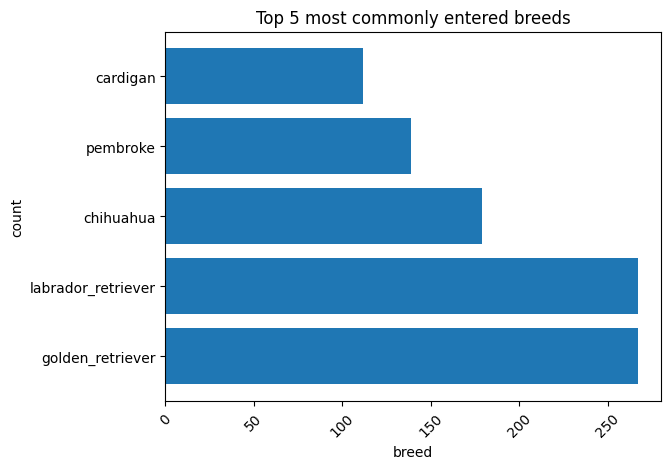

In [38]:
#import matplotlib library for a graph
import matplotlib.pyplot as plt

#create bar plot for most commonly entered dog breeds
plt.barh(data = most_commonly_entered, y = 'breed', width = 'count')
plt.xticks(rotation = 45) #rotate labels by 45 degrees
plt.xlabel("breed")
plt.ylabel("count")
plt.title("Top 5 most commonly entered breeds")
plt.savefig('CommonlyEnteredBreeds.png') # https://stackoverflow.com/questions/13642528/how-to-export-figures-to-files-from-ipython-notebook